<a href="https://colab.research.google.com/github/yuva0567890/APAASSIGNMENT8/blob/main/APA8dataset4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# APA Experiment 8 - Dataset 4
# Load and inspect FAOSTAT dataset
# ============================================================

import os
import glob
import hashlib
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Locate CSV files in Google Colab
# ------------------------------------------------------------

csv_files = glob.glob("/content/*.csv")

print("CSV files found:")

for file_path in csv_files:
    print(file_path)

if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file found in /content. "
        "Please upload the FAOSTAT CSV file again."
    )

# ------------------------------------------------------------
# 2. Select the FAOSTAT CSV file
# ------------------------------------------------------------

faostat_files = [
    file_path
    for file_path in csv_files
    if "FAOSTAT" in os.path.basename(file_path)
    or "faostat" in os.path.basename(file_path)
]

if len(faostat_files) > 0:
    DATA_PATH = faostat_files[0]
else:
    DATA_PATH = csv_files[0]

print("\nSelected dataset:")
print(DATA_PATH)

# ------------------------------------------------------------
# 3. Calculate SHA-256 hash
# ------------------------------------------------------------

sha256_hash = hashlib.sha256()

with open(DATA_PATH, "rb") as file:
    for block in iter(
        lambda: file.read(1024 * 1024),
        b""
    ):
        sha256_hash.update(block)

raw_data_sha256 = sha256_hash.hexdigest()

# ------------------------------------------------------------
# 4. Load dataset
# ------------------------------------------------------------

df4 = pd.read_csv(DATA_PATH)

print("\nDataset loaded successfully.")
print("Number of rows:", df4.shape[0])
print("Number of columns:", df4.shape[1])

# ------------------------------------------------------------
# 5. Display first five rows
# ------------------------------------------------------------

print("\nFirst five rows:")
display(df4.head())

# ------------------------------------------------------------
# 6. Display column names
# ------------------------------------------------------------

print("\nColumn names:")
print(df4.columns.tolist())

# ------------------------------------------------------------
# 7. Display data types
# ------------------------------------------------------------

print("\nData types:")
display(
    df4.dtypes.to_frame(name="Data Type")
)

# ------------------------------------------------------------
# 8. Display missing values
# ------------------------------------------------------------

print("\nMissing-value summary:")
missing_summary = pd.DataFrame({
    "Column": df4.columns,
    "Missing Values": df4.isnull().sum().values,
    "Missing Percentage": (
        df4.isnull().mean().values * 100
    )
})

display(missing_summary)

# ------------------------------------------------------------
# 9. Display duplicate count
# ------------------------------------------------------------

duplicate_count = df4.duplicated().sum()

print("\nNumber of duplicate rows:", duplicate_count)

# ------------------------------------------------------------
# 10. Display numerical summary
# ------------------------------------------------------------

print("\nNumerical summary:")
display(df4.describe(include="all").T)

# ------------------------------------------------------------
# 11. Save initial audit
# ------------------------------------------------------------

initial_audit4 = pd.DataFrame({
    "File Path": [DATA_PATH],
    "File Name": [os.path.basename(DATA_PATH)],
    "Rows": [df4.shape[0]],
    "Columns": [df4.shape[1]],
    "Duplicate Rows": [duplicate_count],
    "SHA256": [raw_data_sha256]
})

initial_audit4.to_csv(
    "dataset4_initial_audit.csv",
    index=False
)

print("\nSaved: dataset4_initial_audit.csv")
print("\nDataset 4 initial inspection completed.")

CSV files found:
/content/FAOSTAT_data_en_9-13-2026 (1).csv

Selected dataset:
/content/FAOSTAT_data_en_9-13-2026 (1).csv

Dataset loaded successfully.
Number of rows: 28528
Number of columns: 15

First five rows:


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,01371,"Almonds, in shell",2020,2020,t,2550.26,X,Value from external organization,Estimated data using trading partners database
1,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,01371,"Almonds, in shell",2020,2020,1000 USD,6853.00,X,Value from external organization,Estimated data using trading partners database
2,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,01371,"Almonds, in shell",2021,2021,t,4488.41,X,Value from external organization,Estimated data using trading partners database
3,TCL,Crops and livestock products,4,Afghanistan,5922,Export value,01371,"Almonds, in shell",2021,2021,1000 USD,7364.00,X,Value from external organization,Estimated data using trading partners database
4,TCL,Crops and livestock products,4,Afghanistan,5910,Export quantity,01371,"Almonds, in shell",2022,2022,t,5035.27,X,Value from external organization,Estimated data using trading partners database



Column names:
['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']

Data types:


,Data Type
Domain Code,object
Domain,object
Area Code (M49),int64
Area,object
Element Code,int64
Element,object
Item Code (CPC),object
Item,object
Year Code,int64
Year,int64



Missing-value summary:


,Column,Missing Values,Missing Percentage
0,Domain Code,0,0.000000
1,Domain,0,0.000000
2,Area Code (M49),0,0.000000
3,Area,0,0.000000
4,Element Code,0,0.000000
5,Element,0,0.000000
6,Item Code (CPC),0,0.000000
7,Item,0,0.000000
8,Year Code,0,0.000000
9,Year,0,0.000000



Number of duplicate rows: 0

Numerical summary:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Domain Code,28528,1,TCL,28528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Domain,28528,1,Crops and livestock products,28528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Code (M49),28528.0,NaN,NaN,NaN,328.088755,217.945478,4.0,159.0,356.0,392.0,784.0
Area,28528,9,Germany,4145,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Element Code,28528.0,NaN,NaN,NaN,5915.99688,6.020299,5907.0,5910.0,5922.0,5922.0,5922.0
Element,28528,2,Export value,14298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item Code (CPC),28528,479,21393.90,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Item,28528,479,"Vegetables, dehydrated",90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year Code,28528.0,NaN,NaN,NaN,2022.032109,1.418774,2020.0,2021.0,2022.0,2023.0,2024.0
Year,28528.0,NaN,NaN,NaN,2022.032109,1.418774,2020.0,2021.0,2022.0,2023.0,2024.0



Saved: dataset4_initial_audit.csv

Dataset 4 initial inspection completed.


In [2]:
# ============================================================
# APA Experiment 8 - Dataset 4
# FAOSTAT category and target inspection
# ============================================================

# ------------------------------------------------------------
# 1. Display unique values in important columns
# ------------------------------------------------------------

important_columns = [
    "Area",
    "Element",
    "Item",
    "Unit",
    "Year"
]

for column_name in important_columns:

    if column_name in df4.columns:

        print("\n" + "=" * 70)
        print(f"Unique values in: {column_name}")
        print("=" * 70)

        unique_values = df4[column_name].dropna().unique()

        print("Number of unique values:", len(unique_values))

        # Display all values for smaller categories
        if len(unique_values) <= 100:
            print(sorted(unique_values.tolist(), key=str))
        else:
            print("First 100 values:")
            print(
                sorted(unique_values.tolist(), key=str)[:100]
            )

# ------------------------------------------------------------
# 2. Display frequency of each element
# ------------------------------------------------------------

print("\nElement frequency:")
display(
    df4["Element"].value_counts(dropna=False)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# 3. Display frequency of each unit
# ------------------------------------------------------------

print("\nUnit frequency:")
display(
    df4["Unit"].value_counts(dropna=False)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# 4. Display year frequency
# ------------------------------------------------------------

print("\nYear frequency:")
display(
    df4["Year"].value_counts(dropna=False)
    .sort_index()
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# 5. Display the most common items
# ------------------------------------------------------------

print("\nTop 30 items:")
display(
    df4["Item"].value_counts()
    .head(30)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# 6. Display the most common areas
# ------------------------------------------------------------

print("\nTop 30 areas:")
display(
    df4["Area"].value_counts()
    .head(30)
    .to_frame(name="Count")
)

# ------------------------------------------------------------
# 7. Display combinations of element and unit
# ------------------------------------------------------------

print("\nElement and unit combinations:")
element_unit_table = (
    df4.groupby(
        ["Element", "Unit"],
        dropna=False
    )
    .size()
    .reset_index(name="Row Count")
    .sort_values(
        by="Row Count",
        ascending=False
    )
)

display(element_unit_table)

# ------------------------------------------------------------
# 8. Display sample records for each element
# ------------------------------------------------------------

print("\nSample records grouped by element:")

for element_name in df4["Element"].dropna().unique():

    print("\nElement:", element_name)

    sample_records = df4[
        df4["Element"] == element_name
    ].head(5)

    display(
        sample_records[
            [
                "Area",
                "Item",
                "Element",
                "Year",
                "Unit",
                "Value",
                "Flag",
                "Note"
            ]
        ]
    )

print("\nDataset 4 category inspection completed.")


Unique values in: Area
Number of unique values: 9
['Afghanistan', 'Bangladesh', 'China', 'Germany', 'India', 'Iran (Islamic Republic of)', 'Japan', 'Republic of Korea', 'United Arab Emirates']

Unique values in: Element
Number of unique values: 2
['Export quantity', 'Export value']

Unique values in: Item
Number of unique values: 479
First 100 values:
['Abaca, manila hemp, raw', 'Almonds, in shell', 'Almonds, shelled', 'Animal oils and fats n.e.c.', 'Animal or vegetable fats and oils and their fractions, chemically modified, except those hydrogenated, inter-esterified, re-esterified or elaidinized; inedible mixtures or preparations of animal or vegetable fats or oils', 'Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw', 'Apple juice', 'Apple juice, concentrated', 'Apples', 'Apricots', 'Apricots, dried', 'Areca nuts', 'Artichokes', 'Asparagus', 'Asses', 'Avocados', 'Bagasse', 'Balata, gutta-percha, guayule, chicle and similar natural gums in primary forms or in

,Count
Element,
Export value,14298
Export quantity,14230



Unit frequency:


,Count
Unit,
1000 USD,14298
t,13946
An,175
1000 An,90
No,19



Year frequency:


...


Sample records grouped by element:

Element: Export quantity


,Area,Item,Element,Year,Unit,Value,Flag,Note
0,Afghanistan,"Almonds, in shell",Export quantity,2020,t,2550.26,X,Estimated data using trading partners database
2,Afghanistan,"Almonds, in shell",Export quantity,2021,t,4488.41,X,Estimated data using trading partners database
4,Afghanistan,"Almonds, in shell",Export quantity,2022,t,5035.27,X,Estimated data using trading partners database
6,Afghanistan,"Almonds, in shell",Export quantity,2023,t,4238.37,X,Estimated data using trading partners database
8,Afghanistan,"Almonds, in shell",Export quantity,2024,t,3664.12,X,Estimated data using trading partners database



Element: Export value


,Area,Item,Element,Year,Unit,Value,Flag,Note
1,Afghanistan,"Almonds, in shell",Export value,2020,1000 USD,6853.0,X,Estimated data using trading partners database
3,Afghanistan,"Almonds, in shell",Export value,2021,1000 USD,7364.0,X,Estimated data using trading partners database
5,Afghanistan,"Almonds, in shell",Export value,2022,1000 USD,7235.0,X,Estimated data using trading partners database
7,Afghanistan,"Almonds, in shell",Export value,2023,1000 USD,7269.0,X,Estimated data using trading partners database
9,Afghanistan,"Almonds, in shell",Export value,2024,1000 USD,5350.0,X,Estimated data using trading partners database



Dataset 4 category inspection completed.


In [3]:
# ============================================================
# APA Experiment 8 - Dataset 4
# FAOSTAT coverage and suitability audit
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Display the complete area list
# ------------------------------------------------------------

print("Available areas:")
display(
    pd.DataFrame({
        "Area": sorted(df4["Area"].dropna().unique())
    })
)

# ------------------------------------------------------------
# 2. Display records for India
# ------------------------------------------------------------

india_df4 = df4[
    df4["Area"].astype(str).str.strip().eq("India")
].copy()

print("\nIndia records:")
print("Number of India records:", len(india_df4))

if len(india_df4) > 0:
    display(india_df4.head(10))

# ------------------------------------------------------------
# 3. Check year coverage by area
# ------------------------------------------------------------

area_year_coverage = (
    df4.groupby("Area")["Year"]
    .agg(
        Number_of_years="nunique",
        Minimum_year="min",
        Maximum_year="max",
        Number_of_records="count"
    )
    .reset_index()
    .sort_values("Number_of_years", ascending=False)
)

print("\nYear coverage by area:")
display(area_year_coverage)

# ------------------------------------------------------------
# 4. Check year coverage by area and element
# ------------------------------------------------------------

area_element_coverage = (
    df4.groupby(
        ["Area", "Element"]
    )["Year"]
    .agg(
        Number_of_years="nunique",
        Minimum_year="min",
        Maximum_year="max",
        Number_of_records="count"
    )
    .reset_index()
    .sort_values(
        ["Area", "Element"]
    )
)

print("\nYear coverage by area and element:")
display(area_element_coverage)

# ------------------------------------------------------------
# 5. Check India's item and element coverage
# ------------------------------------------------------------

if len(india_df4) > 0:

    india_item_element_coverage = (
        india_df4.groupby(
            ["Item", "Element", "Unit"]
        )["Year"]
        .agg(
            Number_of_years="nunique",
            Minimum_year="min",
            Maximum_year="max",
            Number_of_records="count"
        )
        .reset_index()
        .sort_values(
            "Number_of_years",
            ascending=False
        )
    )

    print("\nIndia item-element-unit coverage:")
    display(
        india_item_element_coverage.head(50)
    )

# ------------------------------------------------------------
# 6. Check records with complete five-year coverage
# ------------------------------------------------------------

required_years = {2020, 2021, 2022, 2023, 2024}

complete_five_year_groups = (
    df4.groupby(
        ["Area", "Item", "Element", "Unit"]
    )["Year"]
    .apply(
        lambda year_values:
        set(year_values.astype(int)) == required_years
    )
    .reset_index(name="Complete_2020_2024")
)

complete_five_year_groups = (
    complete_five_year_groups[
        complete_five_year_groups["Complete_2020_2024"]
    ]
    .copy()
)

print(
    "\nNumber of area-item-element-unit groups "
    "with complete 2020-2024 coverage:",
    len(complete_five_year_groups)
)

display(
    complete_five_year_groups.head(50)
)

# ------------------------------------------------------------
# 7. Create a suitability summary
# ------------------------------------------------------------

suitability_summary4 = pd.DataFrame({
    "Check": [
        "Dataset type",
        "Available years",
        "Required minimum years for core experiment",
        "Available elements",
        "India available",
        "Suitable for core district-level rice-yield prediction"
    ],
    "Result": [
        "FAOSTAT country/area-level agricultural trade data",
        "2020-2024",
        "At least 7 complete years",
        "Export quantity and Export value",
        "Yes" if len(india_df4) > 0 else "No",
        "No - only 5 years and no district-level rice-yield target"
    ]
})

print("\nDataset 4 suitability summary:")
display(suitability_summary4)

suitability_summary4.to_csv(
    "dataset4_suitability_summary.csv",
    index=False
)

print("\nSaved: dataset4_suitability_summary.csv")
print("\nDataset 4 coverage audit completed.")

Available areas:


,Area
0,Afghanistan
1,Bangladesh
2,China
3,Germany
4,India
5,Iran (Islamic Republic of)
6,Japan
7,Republic of Korea
8,United Arab Emirates



India records:
Number of India records: 3678


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
12780,TCL,Crops and livestock products,356,India,5910,Export quantity,01371,"Almonds, in shell",2020,2020,t,93.04,A,Official value,NaN
12781,TCL,Crops and livestock products,356,India,5922,Export value,01371,"Almonds, in shell",2020,2020,1000 USD,564.00,A,Official value,NaN
12782,TCL,Crops and livestock products,356,India,5910,Export quantity,01371,"Almonds, in shell",2021,2021,t,393.33,A,Official value,NaN
12783,TCL,Crops and livestock products,356,India,5922,Export value,01371,"Almonds, in shell",2021,2021,1000 USD,1900.00,A,Official value,NaN
12784,TCL,Crops and livestock products,356,India,5910,Export quantity,01371,"Almonds, in shell",2022,2022,t,316.64,A,Official value,NaN
12785,TCL,Crops and livestock products,356,India,5922,Export value,01371,"Almonds, in shell",2022,2022,1000 USD,1610.00,A,Official value,NaN
12786,TCL,Crops and livestock products,356,India,5910,Export quantity,01371,"Almonds, in shell",2023,2023,t,117.11,A,Official value,NaN
12787,TCL,Crops and livestock products,356,India,5922,Export value,01371,"Almonds, in shell",2023,2023,1000 USD,835.00,A,Official value,NaN
12788,TCL,Crops and livestock products,356,India,5910,Export quantity,01371,"Almonds, in shell",2024,2024,t,89.03,A,Official value,NaN
12789,TCL,Crops and livestock products,356,India,5922,Export value,01371,"Almonds, in shell",2024,2024,1000 USD,860.00,A,Official value,NaN



Year coverage by area:


...


Number of area-item-element-unit groups with complete 2020-2024 coverage: 4869


,Area,Item,Element,Unit,Complete_2020_2024
0,Afghanistan,"Almonds, in shell",Export quantity,t,True
1,Afghanistan,"Almonds, in shell",Export value,1000 USD,True
2,Afghanistan,"Almonds, shelled",Export quantity,t,True
3,Afghanistan,"Almonds, shelled",Export value,1000 USD,True
6,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",Export quantity,t,True
7,Afghanistan,"Anise, badian, coriander, cumin, caraway, fenn...",Export value,1000 USD,True
10,Afghanistan,"Apple juice, concentrated",Export quantity,t,True
11,Afghanistan,"Apple juice, concentrated",Export value,1000 USD,True
12,Afghanistan,Apples,Export quantity,t,True
13,Afghanistan,Apples,Export value,1000 USD,True



Dataset 4 suitability summary:


,Check,Result
0,Dataset type,FAOSTAT country/area-level agricultural trade ...
1,Available years,2020-2024
2,Required minimum years for core experiment,At least 7 complete years
3,Available elements,Export quantity and Export value
4,India available,Yes
5,Suitable for core district-level rice-yield pr...,No - only 5 years and no district-level rice-y...



Saved: dataset4_suitability_summary.csv

Dataset 4 coverage audit completed.


In [4]:
# ============================================================
# APA Experiment 8 - Dataset 4
# Search for rice-related items and inspect India data
# ============================================================

# ------------------------------------------------------------
# 1. Search for items containing "rice"
# ------------------------------------------------------------

rice_item_mask = (
    df4["Item"]
    .astype(str)
    .str.lower()
    .str.contains("rice", na=False)
)

rice_items_df4 = df4[
    rice_item_mask
].copy()

print("Number of rice-related records:", len(rice_items_df4))

print("\nRice-related items:")
display(
    pd.DataFrame({
        "Rice-related Item": sorted(
            rice_items_df4["Item"].dropna().unique()
        )
    })
)

# ------------------------------------------------------------
# 2. Filter rice-related records for India
# ------------------------------------------------------------

india_rice_df4 = rice_items_df4[
    rice_items_df4["Area"]
    .astype(str)
    .str.strip()
    .eq("India")
].copy()

print("\nNumber of India rice-related records:")
print(len(india_rice_df4))

if len(india_rice_df4) > 0:

    print("\nIndia rice-related records:")
    display(
        india_rice_df4[
            [
                "Area",
                "Item",
                "Element",
                "Year",
                "Unit",
                "Value",
                "Flag",
                "Flag Description",
                "Note"
            ]
        ]
        .sort_values(
            ["Item", "Element", "Unit", "Year"]
        )
    )

else:
    print(
        "No rice-related records were found for India."
    )

# ------------------------------------------------------------
# 3. Display the number of records by rice item
# ------------------------------------------------------------

if len(india_rice_df4) > 0:

    print("\nIndia rice item frequency:")
    display(
        india_rice_df4["Item"]
        .value_counts()
        .to_frame(name="Record Count")
    )

# ------------------------------------------------------------
# 4. Display the number of records by element and unit
# ------------------------------------------------------------

if len(india_rice_df4) > 0:

    print("\nIndia rice element and unit combinations:")
    display(
        india_rice_df4.groupby(
            ["Item", "Element", "Unit"]
        )
        .size()
        .reset_index(name="Record Count")
        .sort_values(
            "Record Count",
            ascending=False
        )
    )

# ------------------------------------------------------------
# 5. Save rice inspection output
# ------------------------------------------------------------

rice_items_df4.to_csv(
    "dataset4_rice_related_records.csv",
    index=False
)

india_rice_df4.to_csv(
    "dataset4_india_rice_related_records.csv",
    index=False
)

print("\nSaved:")
print("- dataset4_rice_related_records.csv")
print("- dataset4_india_rice_related_records.csv")

print("\nDataset 4 rice-item inspection completed.")

Number of rice-related records: 586

Rice-related items:


,Rice-related Item
0,"Communion wafers, empty cachets of a kind suit..."
1,Flour of rice
2,Husked rice
3,Oil of rice bran
4,Rice
5,"Rice, broken"
6,"Rice, milled"
7,"Rice, milled (husked)"
8,"Rice, paddy (rice milled equivalent)"
9,Rice-fermented beverages



Number of India rice-related records:
60

India rice-related records:


,Area,Item,Element,Year,Unit,Value,Flag,Flag Description,Note
13696,India,"Communion wafers, empty cachets of a kind suit...",Export quantity,2020,t,6031.03,I,Value imputed by a receiving agency,NaN
13698,India,"Communion wafers, empty cachets of a kind suit...",Export quantity,2021,t,8272.63,A,Official value,NaN
13700,India,"Communion wafers, empty cachets of a kind suit...",Export quantity,2022,t,8221.55,I,Value imputed by a receiving agency,NaN
13702,India,"Communion wafers, empty cachets of a kind suit...",Export quantity,2023,t,9746.27,A,Official value,NaN
13704,India,"Communion wafers, empty cachets of a kind suit...",Export quantity,2024,t,9968.44,A,Official value,NaN
13697,India,"Communion wafers, empty cachets of a kind suit...",Export value,2020,1000 USD,17152.00,A,Official value,NaN
13699,India,"Communion wafers, empty cachets of a kind suit...",Export value,2021,1000 USD,23486.00,A,Official value,NaN
13701,India,"Communion wafers, empty cachets of a kind suit...",Export value,2022,1000 USD,26048.00,A,Official value,NaN
13703,India,"Communion wafers, empty cachets of a kind suit...",Export value,2023,1000 USD,28757.00,A,Official value,NaN
13705,India,"Communion wafers, empty cachets of a kind suit...",Export value,2024,1000 USD,29845.00,A,Official value,NaN



India rice item frequency:


,Record Count
Item,
"Communion wafers, empty cachets of a kind suitable for pharmaceutical use, sealing wafers, rice paper and similar products.",10
Husked rice,10
Rice,10
"Rice, broken",10
"Rice, milled",10
"Rice, paddy (rice milled equivalent)",10



India rice element and unit combinations:


,Item,Element,Unit,Record Count
0,"Communion wafers, empty cachets of a kind suit...",Export quantity,t,5
1,"Communion wafers, empty cachets of a kind suit...",Export value,1000 USD,5
2,Husked rice,Export quantity,t,5
3,Husked rice,Export value,1000 USD,5
4,Rice,Export quantity,t,5
5,Rice,Export value,1000 USD,5
6,"Rice, broken",Export quantity,t,5
7,"Rice, broken",Export value,1000 USD,5
8,"Rice, milled",Export quantity,t,5
9,"Rice, milled",Export value,1000 USD,5



Saved:
- dataset4_rice_related_records.csv
- dataset4_india_rice_related_records.csv

Dataset 4 rice-item inspection completed.


In [5]:
# ============================================================
# APA Experiment 8 - Dataset 4
# Final suitability decision and limitation record
# ============================================================

import pandas as pd
from datetime import datetime

# ------------------------------------------------------------
# 1. Select exact India rice records
# ------------------------------------------------------------

india_exact_rice_df4 = df4[
    (df4["Area"].astype(str).str.strip() == "India") &
    (df4["Item"].astype(str).str.strip() == "Rice")
].copy()

india_exact_rice_df4 = india_exact_rice_df4.sort_values(
    ["Element", "Unit", "Year"]
)

print("Exact India Rice records:")
print("Number of records:", len(india_exact_rice_df4))

display(
    india_exact_rice_df4[
        [
            "Area",
            "Item",
            "Element",
            "Year",
            "Unit",
            "Value",
            "Flag",
            "Flag Description",
            "Note"
        ]
    ]
)

# ------------------------------------------------------------
# 2. Check exact Rice year coverage
# ------------------------------------------------------------

exact_rice_years = sorted(
    india_exact_rice_df4["Year"].dropna().unique()
)

print("\nExact India Rice years:")
print(exact_rice_years)

print(
    "Number of unique years:",
    len(exact_rice_years)
)

# ------------------------------------------------------------
# 3. Check whether the core rubric can be satisfied
# ------------------------------------------------------------

minimum_required_years = 7

if len(exact_rice_years) >= minimum_required_years:
    core_rubric_status = "Potentially suitable for chronological modelling"
else:
    core_rubric_status = (
        "Not suitable for core modelling: fewer than 7 years"
    )

# ------------------------------------------------------------
# 4. Prepare a formal suitability record
# ------------------------------------------------------------

dataset4_decision = pd.DataFrame({
    "Field": [
        "Dataset",
        "Dataset type",
        "Geographic level",
        "Selected item",
        "Available years",
        "Number of years",
        "Available target measures",
        "Core assignment requirement",
        "Core rubric status",
        "Reason",
        "Recommended use"
    ],
    "Value": [
        "Dataset 4 - FAOSTAT agricultural trade data",
        "Agricultural export data",
        "Country/area level",
        "India - Rice",
        "2020-2024",
        len(exact_rice_years),
        "Export quantity and export value",
        "At least 7 complete years and district-level rice-yield prediction",
        core_rubric_status,
        (
            "The dataset contains only five years, "
            "has no district-level observations, and "
            "does not contain a direct rice-yield target."
        ),
        (
            "Use as an aggregated descriptive export benchmark "
            "and document its limitations; do not use it as "
            "the core rice-yield model."
        )
    ]
})

print("\nDataset 4 final suitability decision:")
display(dataset4_decision)

# ------------------------------------------------------------
# 5. Save the decision and selected records
# ------------------------------------------------------------

dataset4_decision.to_csv(
    "dataset4_final_suitability_decision.csv",
    index=False
)

india_exact_rice_df4.to_csv(
    "dataset4_india_exact_rice_records.csv",
    index=False
)

print("\nSaved files:")
print("- dataset4_final_suitability_decision.csv")
print("- dataset4_india_exact_rice_records.csv")

print("\nDataset 4 final suitability decision completed.")

Exact India Rice records:
Number of records: 10


,Area,Item,Element,Year,Unit,Value,Flag,Flag Description,Note
15688,India,Rice,Export quantity,2020,t,414411.78,A,Official value,NaN
15690,India,Rice,Export quantity,2021,t,691012.90,A,Official value,NaN
15692,India,Rice,Export quantity,2022,t,460635.15,A,Official value,NaN
15694,India,Rice,Export quantity,2023,t,444995.63,A,Official value,NaN
15696,India,Rice,Export quantity,2024,t,354676.97,A,Official value,NaN
15689,India,Rice,Export value,2020,1000 USD,136318.00,A,Official value,NaN
15691,India,Rice,Export value,2021,1000 USD,209719.00,A,Official value,NaN
15693,India,Rice,Export value,2022,1000 USD,150513.00,A,Official value,NaN
15695,India,Rice,Export value,2023,1000 USD,155910.00,A,Official value,NaN
15697,India,Rice,Export value,2024,1000 USD,116004.00,A,Official value,NaN



Exact India Rice years:
[np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Number of unique years: 5

Dataset 4 final suitability decision:


,Field,Value
0,Dataset,Dataset 4 - FAOSTAT agricultural trade data
1,Dataset type,Agricultural export data
2,Geographic level,Country/area level
3,Selected item,India - Rice
4,Available years,2020-2024
5,Number of years,5
6,Available target measures,Export quantity and export value
7,Core assignment requirement,At least 7 complete years and district-level r...
8,Core rubric status,Not suitable for core modelling: fewer than 7 ...
9,Reason,"The dataset contains only five years, has no d..."



Saved files:
- dataset4_final_suitability_decision.csv
- dataset4_india_exact_rice_records.csv

Dataset 4 final suitability decision completed.


In [6]:
# ============================================================
# APA Experiment 8 - Dataset 4
# EDA preparation for India-Rice export data
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# 1. Create output folders
# ------------------------------------------------------------

os.makedirs("figures_dataset4", exist_ok=True)
os.makedirs("artifacts_dataset4", exist_ok=True)

# ------------------------------------------------------------
# 2. Filter exact India-Rice records
# ------------------------------------------------------------

india_rice_eda = df4[
    (df4["Area"].astype(str).str.strip() == "India") &
    (df4["Item"].astype(str).str.strip() == "Rice")
].copy()

# ------------------------------------------------------------
# 3. Select relevant columns
# ------------------------------------------------------------

india_rice_eda = india_rice_eda[
    [
        "Area",
        "Item",
        "Element",
        "Year",
        "Unit",
        "Value",
        "Flag",
        "Flag Description",
        "Note"
    ]
].copy()

# ------------------------------------------------------------
# 4. Convert data types
# ------------------------------------------------------------

india_rice_eda["Year"] = pd.to_numeric(
    india_rice_eda["Year"],
    errors="coerce"
).astype("Int64")

india_rice_eda["Value"] = pd.to_numeric(
    india_rice_eda["Value"],
    errors="coerce"
)

# Remove invalid year or value records
india_rice_eda = india_rice_eda.dropna(
    subset=["Year", "Value"]
).copy()

india_rice_eda["Year"] = india_rice_eda["Year"].astype(int)

# ------------------------------------------------------------
# 5. Display the cleaned dataset
# ------------------------------------------------------------

print("Cleaned India-Rice EDA dataset:")
print("Number of rows:", len(india_rice_eda))

display(
    india_rice_eda.sort_values(
        ["Element", "Unit", "Year"]
    )
)

# ------------------------------------------------------------
# 6. Check for duplicate analytical keys
# ------------------------------------------------------------

duplicate_key_count = india_rice_eda.duplicated(
    subset=["Area", "Item", "Element", "Year", "Unit"]
).sum()

print("\nDuplicate analytical keys:", duplicate_key_count)

# ------------------------------------------------------------
# 7. Display year coverage
# ------------------------------------------------------------

available_years_dataset4 = sorted(
    india_rice_eda["Year"].unique().tolist()
)

print("\nAvailable years:", available_years_dataset4)
print("Number of unique years:", len(available_years_dataset4))

# ------------------------------------------------------------
# 8. Create year-wise summary
# ------------------------------------------------------------

year_summary_dataset4 = (
    india_rice_eda
    .groupby(
        ["Element", "Unit", "Year"],
        as_index=False
    )["Value"]
    .sum()
    .sort_values(
        ["Element", "Unit", "Year"]
    )
)

print("\nYear-wise India-Rice summary:")
display(year_summary_dataset4)

# ------------------------------------------------------------
# 9. Create separate quantity and value tables
# ------------------------------------------------------------

quantity_dataset4 = india_rice_eda[
    india_rice_eda["Element"].astype(str).str.lower()
    == "export quantity"
].copy()

value_dataset4 = india_rice_eda[
    india_rice_eda["Element"].astype(str).str.lower()
    == "export value"
].copy()

print("\nExport quantity records:")
display(quantity_dataset4)

print("\nExport value records:")
display(value_dataset4)

# ------------------------------------------------------------
# 10. Create a wide-format table
# ------------------------------------------------------------

wide_dataset4 = (
    india_rice_eda
    .pivot_table(
        index="Year",
        columns=["Element", "Unit"],
        values="Value",
        aggfunc="sum"
    )
    .reset_index()
)

# Flatten multi-level column names
wide_dataset4.columns = [
    "_".join(
        [str(part) for part in column if str(part) != ""]
    ).strip("_")
    if isinstance(column, tuple)
    else str(column)
    for column in wide_dataset4.columns
]

print("\nWide-format India-Rice table:")
display(wide_dataset4)

# ------------------------------------------------------------
# 11. Create EDA audit summary
# ------------------------------------------------------------

eda_summary_dataset4 = pd.DataFrame({
    "Check": [
        "Dataset",
        "Geographic scope",
        "Selected item",
        "Number of records",
        "Available years",
        "Number of years",
        "Elements",
        "Duplicate analytical keys",
        "Missing values in Value",
        "EDA interpretation"
    ],
    "Result": [
        "Dataset 4 - FAOSTAT",
        "India",
        "Rice",
        len(india_rice_eda),
        f"{min(available_years_dataset4)}-{max(available_years_dataset4)}",
        len(available_years_dataset4),
        ", ".join(
            sorted(
                india_rice_eda["Element"]
                .dropna()
                .astype(str)
                .unique()
                .tolist()
            )
        ),
        int(duplicate_key_count),
        int(india_rice_eda["Value"].isna().sum()),
        (
            "Five-year country-level export series; "
            "not suitable for the core seven-year "
            "district-level rice-yield experiment."
        )
    ]
})

print("\nDataset 4 EDA summary:")
display(eda_summary_dataset4)

# ------------------------------------------------------------
# 12. Save outputs
# ------------------------------------------------------------

india_rice_eda.to_csv(
    "artifacts_dataset4/dataset4_india_rice_eda.csv",
    index=False
)

year_summary_dataset4.to_csv(
    "artifacts_dataset4/dataset4_india_rice_year_summary.csv",
    index=False
)

wide_dataset4.to_csv(
    "artifacts_dataset4/dataset4_india_rice_wide_table.csv",
    index=False
)

eda_summary_dataset4.to_csv(
    "artifacts_dataset4/dataset4_eda_summary.csv",
    index=False
)

print("\nSaved files:")
print("- artifacts_dataset4/dataset4_india_rice_eda.csv")
print("- artifacts_dataset4/dataset4_india_rice_year_summary.csv")
print("- artifacts_dataset4/dataset4_india_rice_wide_table.csv")
print("- artifacts_dataset4/dataset4_eda_summary.csv")

print("\nDataset 4 EDA preparation completed.")

Cleaned India-Rice EDA dataset:
Number of rows: 10


,Area,Item,Element,Year,Unit,Value,Flag,Flag Description,Note
15688,India,Rice,Export quantity,2020,t,414411.78,A,Official value,NaN
15690,India,Rice,Export quantity,2021,t,691012.90,A,Official value,NaN
15692,India,Rice,Export quantity,2022,t,460635.15,A,Official value,NaN
15694,India,Rice,Export quantity,2023,t,444995.63,A,Official value,NaN
15696,India,Rice,Export quantity,2024,t,354676.97,A,Official value,NaN
15689,India,Rice,Export value,2020,1000 USD,136318.00,A,Official value,NaN
15691,India,Rice,Export value,2021,1000 USD,209719.00,A,Official value,NaN
15693,India,Rice,Export value,2022,1000 USD,150513.00,A,Official value,NaN
15695,India,Rice,Export value,2023,1000 USD,155910.00,A,Official value,NaN
15697,India,Rice,Export value,2024,1000 USD,116004.00,A,Official value,NaN



Duplicate analytical keys: 0

Available years: [2020, 2021, 2022, 2023, 2024]
Number of unique years: 5

Year-wise India-Rice summary:


,Element,Unit,Year,Value
0,Export quantity,t,2020,414411.78
1,Export quantity,t,2021,691012.90
2,Export quantity,t,2022,460635.15
3,Export quantity,t,2023,444995.63
4,Export quantity,t,2024,354676.97
5,Export value,1000 USD,2020,136318.00
6,Export value,1000 USD,2021,209719.00
7,Export value,1000 USD,2022,150513.00
8,Export value,1000 USD,2023,155910.00
9,Export value,1000 USD,2024,116004.00



Export quantity records:


...


Wide-format India-Rice table:


,Year,Export quantity_t,Export value_1000 USD
0,2020,414411.78,136318.0
1,2021,691012.90,209719.0
2,2022,460635.15,150513.0
3,2023,444995.63,155910.0
4,2024,354676.97,116004.0



Dataset 4 EDA summary:


,Check,Result
0,Dataset,Dataset 4 - FAOSTAT
1,Geographic scope,India
2,Selected item,Rice
3,Number of records,10
4,Available years,2020-2024
5,Number of years,5
6,Elements,"Export quantity, Export value"
7,Duplicate analytical keys,0
8,Missing values in Value,0
9,EDA interpretation,Five-year country-level export series; not sui...



Saved files:
- artifacts_dataset4/dataset4_india_rice_eda.csv
- artifacts_dataset4/dataset4_india_rice_year_summary.csv
- artifacts_dataset4/dataset4_india_rice_wide_table.csv
- artifacts_dataset4/dataset4_eda_summary.csv

Dataset 4 EDA preparation completed.


Export quantity descriptive statistics:


,Export Quantity (tonnes)
count,5.000000
mean,473146.486000
std,128354.558238
min,354676.970000
25%,414411.780000
50%,444995.630000
75%,460635.150000
max,691012.900000



Export value descriptive statistics:


,Export Value (1000 USD)
count,5.000000
mean,153692.800000
std,34915.224154
min,116004.000000
25%,136318.000000
50%,150513.000000
75%,155910.000000
max,209719.000000


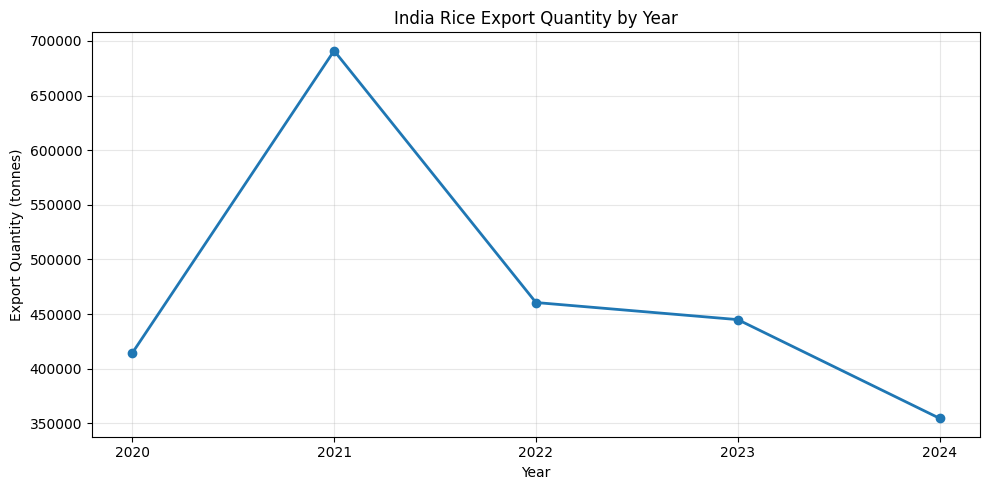

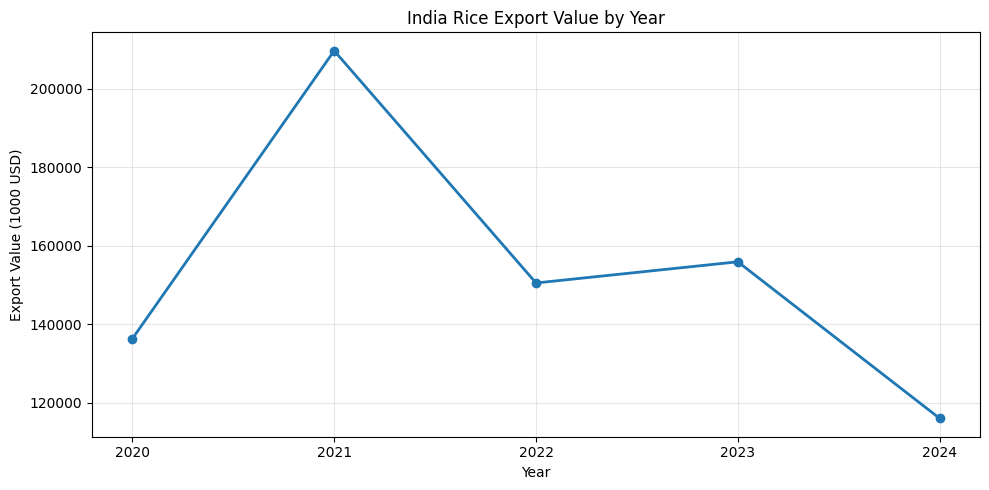

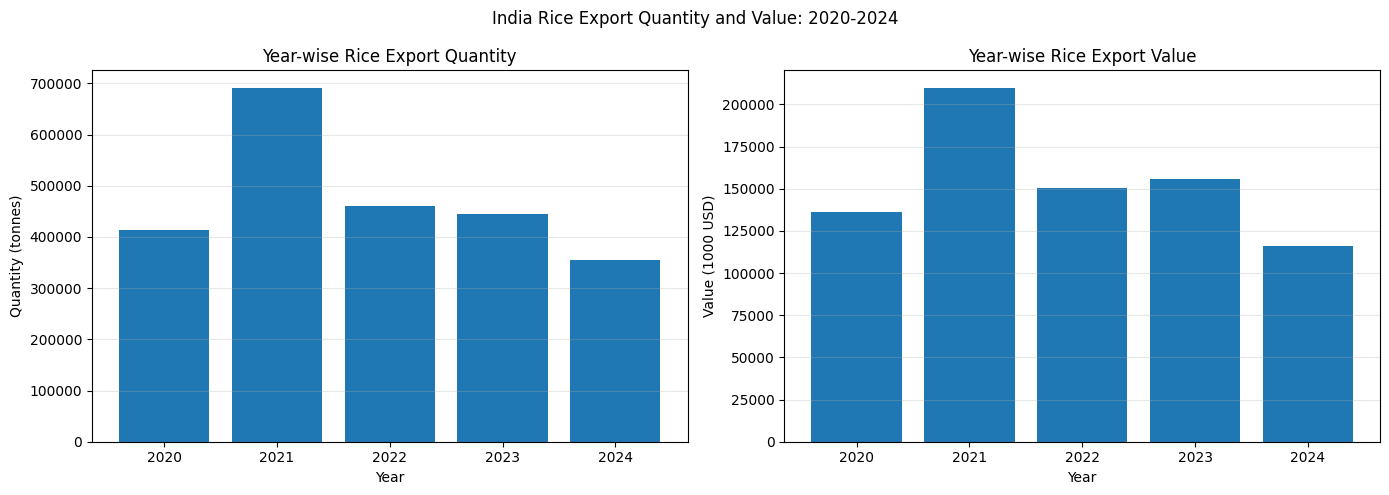


Quantity-value comparison table:


,Year,Export_Quantity_Tonnes,Export_Value_1000_USD
0,2020,414411.78,136318.0
1,2021,691012.90,209719.0
2,2022,460635.15,150513.0
3,2023,444995.63,155910.0
4,2024,354676.97,116004.0


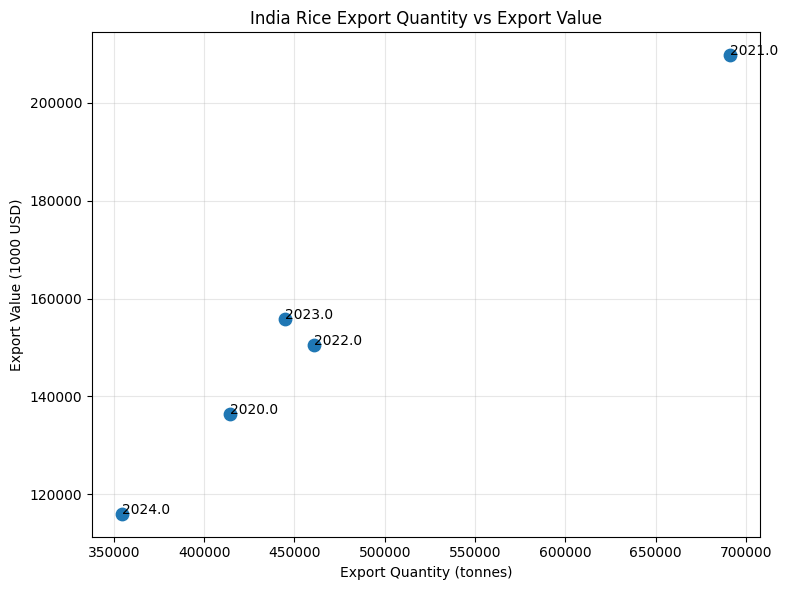


Year-wise percentage changes:


,Year,Export_Quantity_Tonnes,Export_Value_1000_USD,Quantity_Percentage_Change,Value_Percentage_Change
0,2020,414411.78,136318.0,NaN,NaN
1,2021,691012.90,209719.0,66.745477,53.845420
2,2022,460635.15,150513.0,-33.339139,-28.231109
3,2023,444995.63,155910.0,-3.395208,3.585737
4,2024,354676.97,116004.0,-20.296527,-25.595536


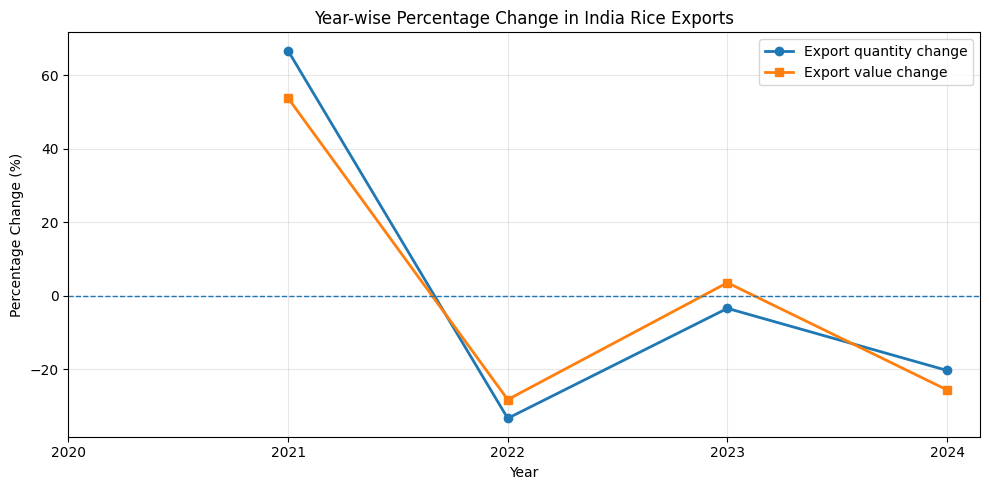


Saved visualization files:
figures_dataset4/dataset4_india_rice_export_quantity_trend.png
figures_dataset4/dataset4_india_rice_export_value_trend.png
figures_dataset4/dataset4_quantity_value_comparison.png
figures_dataset4/dataset4_quantity_vs_value_scatter.png
figures_dataset4/dataset4_percentage_change.png

Saved table:
artifacts_dataset4/dataset4_quantity_value_eda_table.csv

Dataset 4 EDA visualizations completed.


In [7]:
# ============================================================
# APA Experiment 8 - Dataset 4
# Exploratory Data Analysis Visualizations
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. Create output folder
# ------------------------------------------------------------

os.makedirs("figures_dataset4", exist_ok=True)

# ------------------------------------------------------------
# 2. Prepare export quantity and export value data
# ------------------------------------------------------------

quantity_plot_df4 = india_rice_eda[
    (india_rice_eda["Element"] == "Export quantity") &
    (india_rice_eda["Unit"] == "t")
].copy()

value_plot_df4 = india_rice_eda[
    (india_rice_eda["Element"] == "Export value") &
    (india_rice_eda["Unit"] == "1000 USD")
].copy()

quantity_plot_df4 = quantity_plot_df4.sort_values("Year")
value_plot_df4 = value_plot_df4.sort_values("Year")

# ------------------------------------------------------------
# 3. Print descriptive statistics
# ------------------------------------------------------------

print("Export quantity descriptive statistics:")
display(
    quantity_plot_df4["Value"]
    .describe()
    .to_frame(name="Export Quantity (tonnes)")
)

print("\nExport value descriptive statistics:")
display(
    value_plot_df4["Value"]
    .describe()
    .to_frame(name="Export Value (1000 USD)")
)

# ------------------------------------------------------------
# 4. Visualization 1: Export quantity by year
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    quantity_plot_df4["Year"],
    quantity_plot_df4["Value"],
    marker="o",
    linewidth=2
)

plt.title(
    "India Rice Export Quantity by Year"
)

plt.xlabel("Year")
plt.ylabel("Export Quantity (tonnes)")
plt.xticks(
    quantity_plot_df4["Year"]
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures_dataset4/dataset4_india_rice_export_quantity_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 5. Visualization 2: Export value by year
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    value_plot_df4["Year"],
    value_plot_df4["Value"],
    marker="o",
    linewidth=2
)

plt.title(
    "India Rice Export Value by Year"
)

plt.xlabel("Year")
plt.ylabel("Export Value (1000 USD)")
plt.xticks(
    value_plot_df4["Year"]
)
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures_dataset4/dataset4_india_rice_export_value_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 6. Visualization 3: Export quantity and value comparison
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

axes[0].bar(
    quantity_plot_df4["Year"].astype(str),
    quantity_plot_df4["Value"]
)

axes[0].set_title(
    "Year-wise Rice Export Quantity"
)

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Quantity (tonnes)")
axes[0].grid(
    axis="y",
    alpha=0.3
)

axes[1].bar(
    value_plot_df4["Year"].astype(str),
    value_plot_df4["Value"]
)

axes[1].set_title(
    "Year-wise Rice Export Value"
)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Value (1000 USD)")
axes[1].grid(
    axis="y",
    alpha=0.3
)

plt.suptitle(
    "India Rice Export Quantity and Value: 2020-2024"
)

plt.tight_layout()

plt.savefig(
    "figures_dataset4/dataset4_quantity_value_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7. Visualization 4: Relationship between quantity and value
# ------------------------------------------------------------

quantity_value_comparison = pd.merge(
    quantity_plot_df4[
        ["Year", "Value"]
    ].rename(
        columns={
            "Value": "Export_Quantity_Tonnes"
        }
    ),
    value_plot_df4[
        ["Year", "Value"]
    ].rename(
        columns={
            "Value": "Export_Value_1000_USD"
        }
    ),
    on="Year",
    how="inner"
)

print("\nQuantity-value comparison table:")
display(quantity_value_comparison)

plt.figure(figsize=(8, 6))

plt.scatter(
    quantity_value_comparison[
        "Export_Quantity_Tonnes"
    ],
    quantity_value_comparison[
        "Export_Value_1000_USD"
    ],
    s=80
)

for _, row in quantity_value_comparison.iterrows():

    plt.annotate(
        str(row["Year"]),
        (
            row["Export_Quantity_Tonnes"],
            row["Export_Value_1000_USD"]
        )
    )

plt.title(
    "India Rice Export Quantity vs Export Value"
)

plt.xlabel("Export Quantity (tonnes)")
plt.ylabel("Export Value (1000 USD)")
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures_dataset4/dataset4_quantity_vs_value_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8. Visualization 5: Year-wise percentage change
# ------------------------------------------------------------

quantity_value_comparison = (
    quantity_value_comparison
    .sort_values("Year")
    .copy()
)

quantity_value_comparison[
    "Quantity_Percentage_Change"
] = (
    quantity_value_comparison[
        "Export_Quantity_Tonnes"
    ]
    .pct_change()
    * 100
)

quantity_value_comparison[
    "Value_Percentage_Change"
] = (
    quantity_value_comparison[
        "Export_Value_1000_USD"
    ]
    .pct_change()
    * 100
)

print("\nYear-wise percentage changes:")
display(quantity_value_comparison)

plt.figure(figsize=(10, 5))

plt.plot(
    quantity_value_comparison["Year"],
    quantity_value_comparison[
        "Quantity_Percentage_Change"
    ],
    marker="o",
    linewidth=2,
    label="Export quantity change"
)

plt.plot(
    quantity_value_comparison["Year"],
    quantity_value_comparison[
        "Value_Percentage_Change"
    ],
    marker="s",
    linewidth=2,
    label="Export value change"
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Year-wise Percentage Change in India Rice Exports"
)

plt.xlabel("Year")
plt.ylabel("Percentage Change (%)")
plt.xticks(
    quantity_value_comparison["Year"]
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures_dataset4/dataset4_percentage_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9. Save combined EDA table
# ------------------------------------------------------------

quantity_value_comparison.to_csv(
    "artifacts_dataset4/dataset4_quantity_value_eda_table.csv",
    index=False
)

print("\nSaved visualization files:")
print(
    "figures_dataset4/"
    "dataset4_india_rice_export_quantity_trend.png"
)

print(
    "figures_dataset4/"
    "dataset4_india_rice_export_value_trend.png"
)

print(
    "figures_dataset4/"
    "dataset4_quantity_value_comparison.png"
)

print(
    "figures_dataset4/"
    "dataset4_quantity_vs_value_scatter.png"
)

print(
    "figures_dataset4/"
    "dataset4_percentage_change.png"
)

print(
    "\nSaved table:"
)
print(
    "artifacts_dataset4/"
    "dataset4_quantity_value_eda_table.csv"
)

print("\nDataset 4 EDA visualizations completed.")

In [8]:
# ============================================================
# DATASET 4: FINAL SUITABILITY DECISION AND ARTIFACT SUMMARY
# ============================================================

import os
import json
import pandas as pd
from datetime import datetime

DATASET_NAME = "Dataset 4 - FAOSTAT India Rice Export Data"

suitability_decision = {
    "dataset": DATASET_NAME,
    "dataset_role": "Aggregated descriptive benchmark",
    "geographic_scope": "Country-level",
    "selected_area": "India",
    "selected_item": "Rice",
    "available_years": [2020, 2021, 2022, 2023, 2024],
    "number_of_years": 5,
    "required_minimum_years_for_core": 7,
    "available_elements": [
        "Export quantity",
        "Export value"
    ],
    "target_for_core_prediction": "Not available",
    "required_predictors_for_core": [
        "state",
        "district",
        "season",
        "year"
    ],
    "available_predictors": [
        "year",
        "element"
    ],
    "core_modeling_status": "NOT SUITABLE",
    "reason": (
        "Dataset 4 is country-level export data and does not contain "
        "district-wise crop production, crop area, crop yield, season, "
        "or the required predictor variables. It also contains only "
        "five years, while the assignment requires at least seven "
        "complete years for the core experiment."
    ),
    "completed_activities": [
        "Initial data inspection",
        "Missing-value inspection",
        "Duplicate inspection",
        "Category inspection",
        "India filtering",
        "Rice filtering",
        "Year coverage analysis",
        "Descriptive statistics",
        "Year-wise trend visualizations",
        "Quantity and value comparison visualizations",
        "Percentage-change visualization"
    ],
    "recommended_use": (
        "Use as an aggregated descriptive export benchmark only. "
        "Do not train the core crop-yield prediction models on this dataset."
    ),
    "decision_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

# Display the final decision
dataset4_suitability_df = pd.DataFrame(
    list(suitability_decision.items()),
    columns=["Check", "Result"]
)

display(dataset4_suitability_df)

# Save final suitability decision
os.makedirs("artifacts_dataset4", exist_ok=True)

dataset4_suitability_df.to_csv(
    "artifacts_dataset4/dataset4_final_suitability_decision.csv",
    index=False
)

with open(
    "artifacts_dataset4/dataset4_final_suitability_decision.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(suitability_decision, file, indent=4)

print("Dataset 4 final suitability decision saved successfully.")
print("Folder: artifacts_dataset4/")
print("Status: Dataset 4 is suitable only for descriptive benchmark analysis.")

,Check,Result
0,dataset,Dataset 4 - FAOSTAT India Rice Export Data
1,dataset_role,Aggregated descriptive benchmark
2,geographic_scope,Country-level
3,selected_area,India
4,selected_item,Rice
5,available_years,"[2020, 2021, 2022, 2023, 2024]"
6,number_of_years,5
7,required_minimum_years_for_core,7
8,available_elements,"[Export quantity, Export value]"
9,target_for_core_prediction,Not available


Dataset 4 final suitability decision saved successfully.
Folder: artifacts_dataset4/
Status: Dataset 4 is suitable only for descriptive benchmark analysis.
